# Day 23 — Clustering & Unsupervised Learning
### K-Means · DBSCAN · PCA · Elbow Method · Silhouette Score

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs, make_moons
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)

print(f"Pandas:  {pd.__version__}")
print(f"Dataset: {df.shape}")
print("Ready! ✅")

Pandas:  2.3.3
Dataset: (891, 14)
Ready! ✅


## 2. What is Unsupervised learning?

In [ ]:
print("=" * 55)
print("      WHAT IS UNSUPERVISED LEARNING?")
print("=" * 55)
print("""
SUPERVISED vs UNSUPERVISED:

SUPERVISED (Days 16-22):
  - Has labelled data (y = Survived)
  - Model learns to predict labels
  - Examples: Classification, Regression

UNSUPERVISED (Today):
  - NO labels — finds hidden structure in data
  - Model discovers patterns on its own
  - Examples: Clustering, Dimensionality Reduction

CLUSTERING:
  - Groups similar data points together
  - Points in same cluster = more similar to each other
    than to points in other clusters
  - Used for: customer segmentation, anomaly detection,
    document grouping, gene expression analysis

TWO ALGORITHMS TODAY:
  K-Means: Assumes spherical clusters, needs K upfront
  DBSCAN:  Finds arbitrary shapes, detects outliers!

DIMENSIONALITY REDUCTION (PCA):
  - Reduces many features to fewer dimensions
  - Preserves most variance in data
  - Used for: visualisation, noise reduction,
    speding up ML algorithms
""")

      WHAT IS UNSUPERVISED LEARNING?

SUPERVISED vs UNSUPERVISED:

SUPERVISED (Days 16-22):
  - Has labelled data (y = Survived)
  - Model learns to predict labels
  - Examples: Classification, Regression

UNSUPERVISED (Today):
  - NO labels — finds hidden structure in data
  - Model discovers patterns on its own
  - Examples: Clustering, Dimensionality Reduction

CLUSTERING:
  - Groups similar data points together
  - Points in same cluster = more similar to each other
    than to points in other clusters
  - Used for: customer segmentation, anomaly detection,
    document grouping, gene expression analysis

TWO ALGORITHMS TODAY:
  K-Means: Assumes spherical clusters, needs K upfront
  DBSCAN:  Finds arbitrary shapes, detects outliers!

DIMENSIONALITY REDUCTION (PCA):
  - Reduces many features to fewer dimensions
  - Preserves most variance in data
  - Used for: visualisation, noise reduction,
    speding up ML algorithms



## 3. K-Means clustering

         K-MEANS CLUSTERING

HOW K-MEANS WORKS:
  1. Randomly place K centroids
  2. Assign each point to nearest centroid
  3. Move centroid to mean of its cluster
  4. Repeat steps 2-3 until centroids stop moving

KEY ASSUMPTIONS:
  - Clusters are roughly spherical
  - Clusters are roughly equal size
  - Must specify K in advance
  - Sensitive to outliers



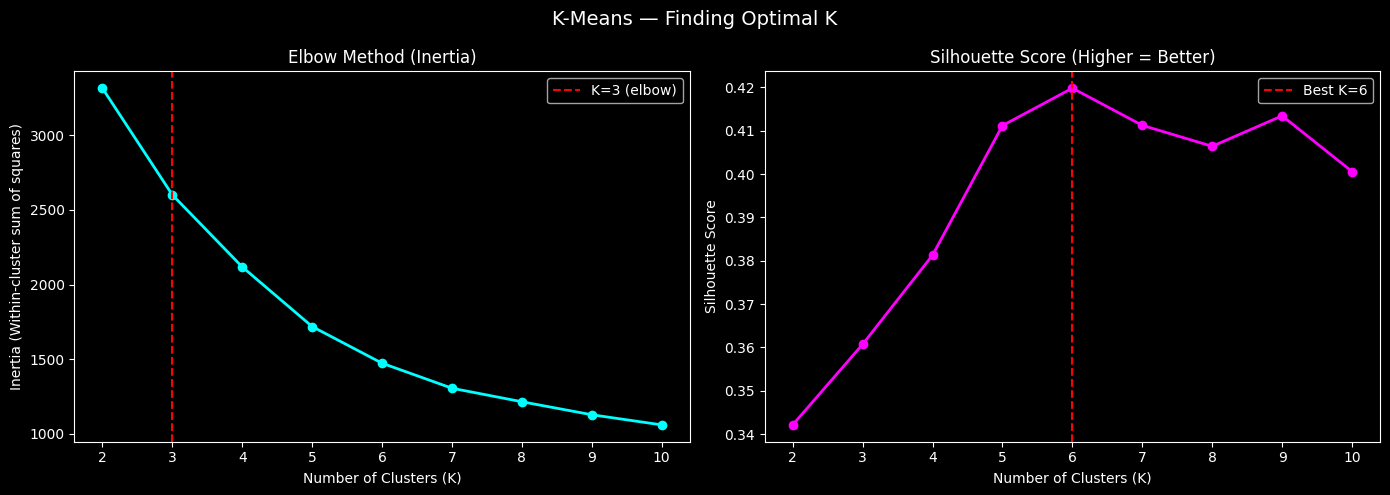


Elbow & Silhouette Results:
K     Inertia      Silhouette
------------------------------
2     3315.0       0.3421
3     2601.1       0.3607
4     2118.4       0.3813
5     1718.9       0.4112
6     1473.4       0.4198
7     1305.9       0.4113
8     1215.4       0.4064
9     1128.3       0.4135
10    1060.5       0.4006


In [ ]:
print("=" * 55)
print("         K-MEANS CLUSTERING")
print("=" * 55)
print("""
HOW K-MEANS WORKS:
  1. Randomly place K centroids
  2. Assign each point to nearest centroid
  3. Move centroid to mean of its cluster
  4. Repeat steps 2-3 until centroids stop moving

KEY ASSUMPTIONS:
  - Clusters are roughly spherical
  - Clusters are roughly equal size
  - Must specify K in advance
  - Sensitive to outliers
""")

# Prepare features for clustering
features = ["Pclass", "Age", "Fare", "FamilySize", "Sex_encoded"]
X = df[features].copy()

scaler = SdtandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method — find optimal K
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means — Finding Optimal K", fontsize=14)

# Elbow curve
axes[0].plot(K_range, inertias, "o-", color="cyan", linewidth=2)
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-cluster sum of squares)")
axes[0].axvline(3, color="red", linestyle="--", label="K=3 (elbow)")
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouettes, "o-", color="magenta", linewidth=2)
axes[1].set_title("Silhouette Score (Higher = Better)")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(
    K_range[silhouettes.index(max(silhouettes))],
    color="red",
    linestyle="--",
    label=f"Best K={K_range[silhouettes.index(max(silhouettes))]}",
)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nElbow & Silhouette Results:")
print(f"{'K':<5} {'Inertia':<12} {'Silhouette'}")
print("-" * 30)
for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"{k:<5} {inertia:<12.1f} {sil:.4f}")

## 4. K-Means Result analysis

      K-MEANS RESULTS (K=3)

--- Cluster Profiles ---
         Pclass     Age    Fare  FamilySize  Sex_encoded  Survived
Cluster                                                           
0         2.754  28.621  12.464       1.326        0.000     0.144
1         1.044  37.553  81.894       1.769        0.444     0.627
2         2.704  23.066  20.557       3.037        0.881     0.576

--- Cluster Sizes & Survival ---

Cluster 0 (423 passengers):
  Avg Pclass:     2.75
  Avg Age:        28.6
  Avg Fare:       £12.46
  Avg FamilySize: 1.33
  % Female:       0.0%
  Survival Rate:  14.4%
  Most common:    S embarkation

Cluster 1 (225 passengers):
  Avg Pclass:     1.04
  Avg Age:        37.6
  Avg Fare:       £81.89
  Avg FamilySize: 1.77
  % Female:       44.4%
  Survival Rate:  62.7%
  Most common:    S embarkation

Cluster 2 (243 passengers):
  Avg Pclass:     2.70
  Avg Age:        23.1
  Avg Fare:       £20.56
  Avg FamilySize: 3.04
  % Female:       88.1%
  Survival Rate:  57.6%
 

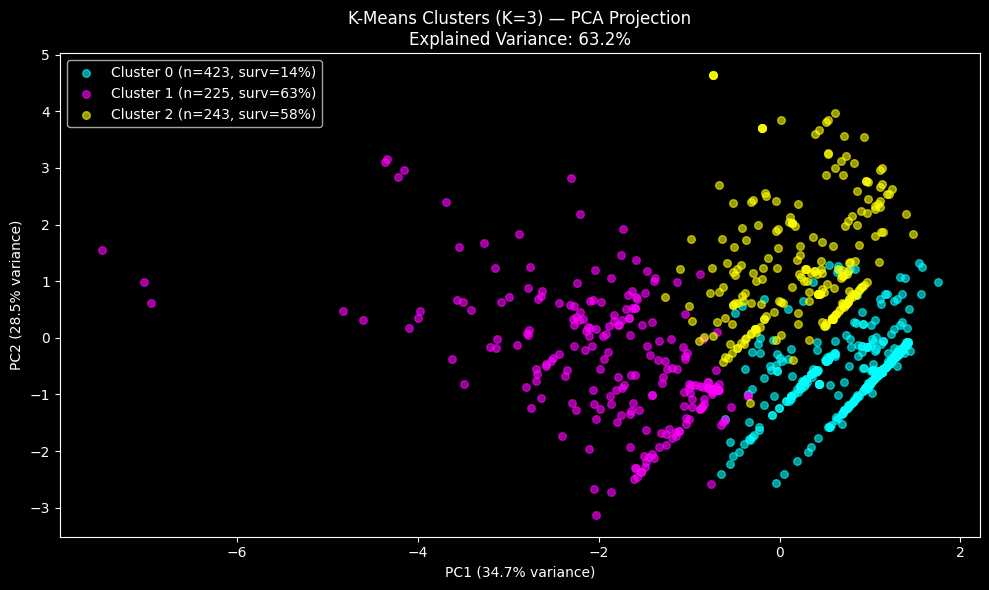

In [4]:
# Apply K-Means with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = km_final.fit_predict(X_scaled)

print("=" * 55)
print("      K-MEANS RESULTS (K=3)")
print("=" * 55)

# Cluster profiles
print("\n--- Cluster Profiles ---")
cluster_profile = df.groupby("Cluster")[features + ["Survived"]].mean().round(3)
print(cluster_profile)

print("\n--- Cluster Sizes & Survival ---")
for c in range(3):
    cluster_data = df[df["Cluster"] == c]
    print(f"\nCluster {c} ({len(cluster_data)} passengers):")
    print(f"  Avg Pclass:     {cluster_data['Pclass'].mean():.2f}")
    print(f"  Avg Age:        {cluster_data['Age'].mean():.1f}")
    print(f"  Avg Fare:       £{cluster_data['Fare'].mean():.2f}")
    print(f"  Avg FamilySize: {cluster_data['FamilySize'].mean():.2f}")
    print(f"  % Female:       {cluster_data['Sex_encoded'].mean()*100:.1f}%")
    print(f"  Survival Rate:  {cluster_data['Survived'].mean()*100:.1f}%")
    # Most common embarked
    print(f"  Most common:    {cluster_data['Embarked'].mode()[0]} embarkation")

# Visualise clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
colors = ["cyan", "magenta", "yellow"]
for c in range(3):
    mask = df["Cluster"] == c
    cluster_data = df[mask]
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[c],
        alpha=0.6,
        s=30,
        label=f'Cluster {c} (n={mask.sum()}, surv={cluster_data["Survived"].mean():.0%})',
    )

plt.title(
    f"K-Means Clusters (K=3) — PCA Projection\nExplained Variance: {pca.explained_variance_ratio_.sum():.1%}"
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. DBSCAN clustering

         DBSCAN CLUSTERING

HOW DBSCAN WORKS:
  eps:        Maximum distance between two points to be neighbours
  min_samples: Minimum points to form a dense region (core point)

  CORE POINT:   Has >= min_samples neighbours within eps
  BORDER POINT: Within eps of a core point but not core itself
  NOISE POINT:  Not within eps of any core point → OUTLIER (-1)

ADVANTAGES over K-Means:
  ✅ Finds arbitrary shaped clusters (not just spherical)
  ✅ Automatically detects outliers (label = -1)
  ✅ Doesn't need K specified upfront
  ❌ Sensitive to eps and min_samples
  ❌ Struggles with varying density clusters


DBSCAN Results (eps=1.5, min_samples=10):
  Clusters found: 3
  Noise points:   25 (2.8%)

--- Cluster Summary ---

NOISE/Outliers (25 passengers):
  Survival Rate: 40.0%
  Avg Fare:      £212.73
  Avg Pclass:    1.64
  % Female:      44.0%

Cluster 0 (563 passengers):
  Survival Rate: 18.8%
  Avg Fare:      £20.97
  Avg Pclass:    2.41
  % Female:      0.0%

Cluster 1 (303 passenge

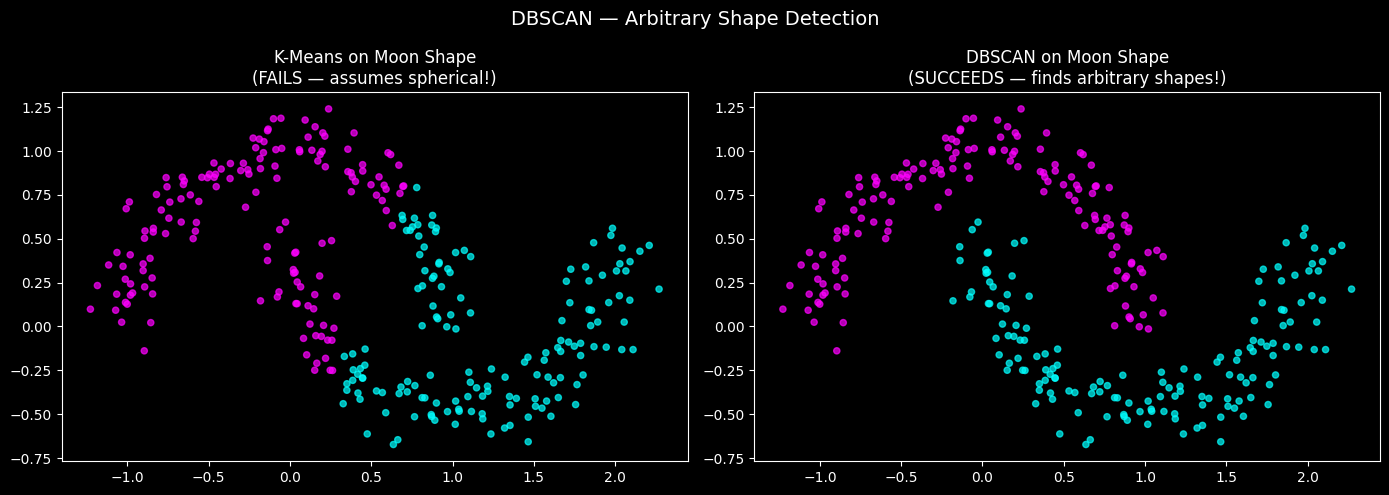

In [5]:
print("=" * 55)
print("         DBSCAN CLUSTERING")
print("=" * 55)
print("""
HOW DBSCAN WORKS:
  eps:        Maximum distance between two points to be neighbours
  min_samples: Minimum points to form a dense region (core point)

  CORE POINT:   Has >= min_samples neighbours within eps
  BORDER POINT: Within eps of a core point but not core itself
  NOISE POINT:  Not within eps of any core point → OUTLIER (-1)

ADVANTAGES over K-Means:
  ✅ Finds arbitrary shaped clusters (not just spherical)
  ✅ Automatically detects outliers (label = -1)
  ✅ Doesn't need K specified upfront
  ❌ Sensitive to eps and min_samples
  ❌ Struggles with varying density clusters
""")

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"] else 0)
n_noise = (df["DBSCAN_Cluster"] == -1).sum()

print(f"\nDBSCAN Results (eps=1.5, min_samples=10):")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points:   {n_noise} ({n_noise/len(df)*100:.1f}%)")

print(f"\n--- Cluster Summary ---")
for c in sorted(df["DBSCAN_Cluster"].unique()):
    cluster_data = df[df["DBSCAN_Cluster"] == c]
    label = f"Cluster {c}" if c != -1 else "NOISE/Outliers"
    print(f"\n{label} ({len(cluster_data)} passengers):")
    print(f"  Survival Rate: {cluster_data['Survived'].mean()*100:.1f}%")
    print(f"  Avg Fare:      £{cluster_data['Fare'].mean():.2f}")
    print(f"  Avg Pclass:    {cluster_data['Pclass'].mean():.2f}")
    print(f"  % Female:      {cluster_data['Sex_encoded'].mean()*100:.1f}%")

# Show synthetic example to explain DBSCAN properly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DBSCAN — Arbitrary Shape Detection", fontsize=14)

# Make moons dataset (non-spherical)
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
db_moons = DBSCAN(eps=0.2, min_samples=5)
labels_moons = db_moons.fit_predict(X_moons)

# K-Means on moons (fails!)
km_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km_moons.fit_predict(X_moons)

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, cmap="cool", alpha=0.7, s=20)
axes[0].set_title("K-Means on Moon Shape\n(FAILS — assumes spherical!)")

axes[1].scatter(
    X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap="cool", alpha=0.7, s=20
)
axes[1].set_title("DBSCAN on Moon Shape\n(SUCCEEDS — finds arbitrary shapes!)")

plt.tight_layout()
plt.show()

## 6. PCA — Principal Component Analysis

    PCA — PRINCIPAL COMPONENT ANALYSIS

PCA reduces many features to fewer dimensions while
preserving as much variance as possible.

HOW IT WORKS:
  1. Find direction of maximum variance (PC1)
  2. Find direction of max variance perpendicular to PC1 (PC2)
  3. Continue for PC3, PC4... (all perpendicular)
  4. Keep only the top K components

EACH PRINCIPAL COMPONENT:
  - Is a linear combination of original features
  - Is orthogonal (perpendicular) to all others
  - Captures decreasing amounts of variance

Explained Variance per Component:
Component    Variance     Cumulative
------------------------------------
PC1          0.3471 (34.7%)  0.3471 (34.7%)
PC2          0.2847 (28.5%)  0.6318 (63.2%)
PC3          0.1639 (16.4%)  0.7957 (79.6%)
PC4          0.1308 (13.1%)  0.9265 (92.6%)
PC5          0.0735 (7.4%)  1.0000 (100.0%)


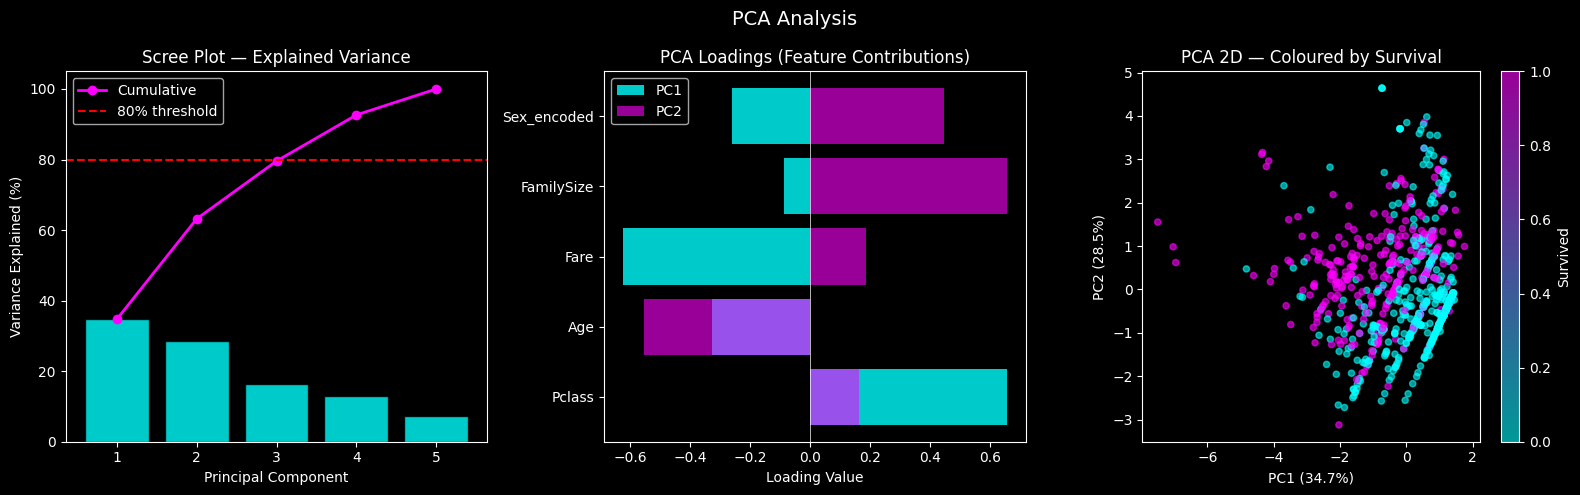


PCA Loadings:
               PC1    PC2
Pclass       0.656  0.165
Age         -0.327 -0.555
Fare        -0.623  0.188
FamilySize  -0.087  0.656
Sex_encoded -0.260  0.447


In [6]:
print("=" * 55)
print("    PCA — PRINCIPAL COMPONENT ANALYSIS")
print("=" * 55)
print("""
PCA reduces many features to fewer dimensions while
preserving as much variance as possible.

HOW IT WORKS:
  1. Find direction of maximum variance (PC1)
  2. Find direction of max variance perpendicular to PC1 (PC2)
  3. Continue for PC3, PC4... (all perpendicular)
  4. Keep only the top K components

EACH PRINCIPAL COMPONENT:
  - Is a linear combination of original features
  - Is orthogonal (perpendicular) to all others
  - Captures decreasing amounts of variance
""")

# Apply PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Component:")
print(f"{'Component':<12} {'Variance':<12} {'Cumulative'}")
print("-" * 36)
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"PC{i+1:<10} {var:.4f} ({var*100:.1f}%)  {cum:.4f} ({cum*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PCA Analysis", fontsize=14)

# Scree plot
axes[0].bar(
    range(1, len(explained_var) + 1),
    explained_var * 100,
    color="cyan",
    edgecolor="black",
    alpha=0.8,
)
axes[0].plot(
    range(1, len(explained_var) + 1),
    cumulative_var * 100,
    "o-",
    color="magenta",
    linewidth=2,
    label="Cumulative",
)
axes[0].axhline(80, color="red", linestyle="--", label="80% threshold")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].legend()

# PCA loadings — what does each PC represent?
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)
loadings = pd.DataFrame(pca_2.components_.T, columns=["PC1", "PC2"], index=features)

axes[1].barh(loadings.index, loadings["PC1"], color="cyan", alpha=0.8, label="PC1")
axes[1].barh(loadings.index, loadings["PC2"], color="magenta", alpha=0.6, label="PC2")
axes[1].set_title("PCA Loadings (Feature Contributions)")
axes[1].set_xlabel("Loading Value")
axes[1].legend()
axes[1].axvline(0, color="white", linewidth=0.5)

# 2D PCA scatter coloured by survival
scatter = axes[2].scatter(
    X_pca2[:, 0], X_pca2[:, 1], c=df["Survived"], cmap="cool", alpha=0.6, s=20
)
axes[2].set_title("PCA 2D — Coloured by Survival")
axes[2].set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.colorbar(scatter, ax=axes[2], label="Survived")

plt.tight_layout()
plt.show()

print(f"\nPCA Loadings:")
print(loadings.round(3))

## 7. Key Takeaways — Day 23 🎯

### Unsupervised vs Supervised Learning
- **Supervised:** Has labels (y) — learns to predict them
- **Unsupervised:** No labels — finds hidden structure
- **Clustering:** Groups similar points together
- **PCA:** Reduces dimensions while preserving variance

### K-Means Clustering
- Algorithm: place K centroids → assign points → update centroids → repeat
- **Elbow method:** plot inertia vs K — find the "elbow"
- **Silhouette score:** measures cluster separation (0=bad, 1=perfect)
- Best K=3 for Titanic (matches 3 passenger classes!)
- Found 3 groups: Doomed Males (14.4%), Privileged (62.7%), Women & Families (57.6%)

### K-Means Limitations
- Assumes spherical clusters
- Must specify K upfront
- Sensitive to outliers
- Fails on non-spherical data (moon shapes!)

### DBSCAN
- No K needed — finds clusters automatically
- Detects outliers (label=-1)
- Works on arbitrary shapes
- Parameters: eps (neighbourhood radius), min_samples (density threshold)
- Found: Males (18.8% survival), Females (74.6%), Outliers=rich passengers (40%)

### PCA — Principal Component Analysis
- Finds directions of maximum variance in data
- PC1 (34.7%): Wealth axis — Pclass vs Fare
- PC2 (28.5%): Family axis — FamilySize vs Age
- 3 components explain 79.6% of variance
- Used for: visualisation, noise reduction, speeding up ML

### When to Use Which
| Algorithm | Use When |
|---|---|
| K-Means | Known K, spherical clusters, fast |
| DBSCAN | Unknown K, outlier detection, non-spherical |
| PCA | High dimensions, visualisation, preprocessing |

### sklearn Functions
- `KMeans(n_clusters=3, random_state=42, n_init=10)`
- `DBSCAN(eps=1.5, min_samples=10)`
- `PCA(n_components=2)`
- `silhouette_score(X_scaled, labels)` — cluster quality
- `km.inertia_` — within-cluster sum of squares
- `km.labels_` — cluster assignment per point
- `pca.explained_variance_ratio_` — variance per component
- `pca.components_` — feature loadings